In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random, math, copy
import importlib
import nn
importlib.reload(nn)
from nn import NeuralNetwork

In [3]:
multimodal_train = pd.read_csv("dane_ae3/multimodal-large-training.csv")
multimodal_train.head()
X_multimodal_train = multimodal_train['x'].values.reshape(-1, 1)
y_multimodal_train = multimodal_train['y'].values.reshape(-1, 1)

multimodal_test = pd.read_csv("dane_ae3/multimodal-large-test.csv")
multimodal_test.head()
X_multimodal_test = multimodal_test['x'].values.reshape(-1, 1)
y_multimodal_test = multimodal_test['y'].values.reshape(-1, 1)

In [4]:
nn_test = NeuralNetwork(X_multimodal_train, y_multimodal_train, [1, 32, 32, 32, 1],
                              activation_fun="sigmoid", output_activation="linear", loss_fun="mse")

In [5]:
weights, biases = nn_test.get_weights()

In [38]:
class NeuralNetworkEvolution:
    def __init__(self, architecture, X, Y,
                activation_fun, output_activation, loss_fun,
                population_size=25, random_draw=False):
        self.architecture = architecture
        self.population_size = population_size
        self.activation_fun = activation_fun
        self.output_activation = output_activation
        self.loss_fun = loss_fun
        self.random_draw = random_draw
        self.X = X
        self.Y = Y
        self.generation = self.generate_population(population_size)
        self.best_individual = None
        self.best_fitness = float('inf')
        self.fitness_history = []

    def generate_population(self, population_size):
        population = []
        for _ in range(population_size):
            nn = self.generate_individual()
            population.append(nn)
        return population
    
    def generate_individual(self):
        nn = NeuralNetwork(self.X, self.Y, self.architecture,
                            activation_fun=self.activation_fun,
                            output_activation=self.output_activation,
                            loss_fun=self.loss_fun, random_draw=self.random_draw)
        return nn
    
    def _evaluate_fitness(self, individual):
        predictions = individual.predict(self.X)
        loss = individual.loss(predictions, self.Y)
        return loss
    
    def _crossover(self, parent1, parent2):
        weights1, biases1 = parent1.get_weights()
        weights2, biases2 = parent2.get_weights()

        new_weights = []
        new_biases = []

        for i in range(len(weights1)):
            w1, w2 = weights1[i], weights2[i]
            b1, b2 = biases1[i], biases2[i]

            # Rozmiary kolumn (liczba neuronów w następnej warstwie)
            layer_size = w1.shape[1]
            if layer_size < 2:
                crossover_point = 1  # żeby hstack nie dostał pustego zakresu
            else:
                crossover_point = random.randint(1, layer_size - 1)

            new_w = np.hstack([
                w1[:, :crossover_point],
                w2[:, crossover_point:]
            ])
            new_b = np.hstack([
                b1[:, :crossover_point],
                b2[:, crossover_point:]
            ])

            new_weights.append(new_w.copy())
            new_biases.append(new_b.copy())

        child = self.generate_individual()
        child.set_weights(new_weights, new_biases)
        return child

    def mutate(self, individual, mutation_rate=0.3, mutation_strength=0.1):
        weights, biases = individual.get_weights()

        for i in range(len(weights)):
            for row in range(weights[i].shape[0]):
                for col in range(weights[i].shape[1]):
                    if random.random() < mutation_rate:
                        weights[i][row, col] += np.random.normal(0, mutation_strength)

        for i in range(len(biases)):
            for j in range(biases[i].shape[0]):
                if random.random() < mutation_rate:
                    biases[i][j] += np.random.normal(0, mutation_strength)

        individual.set_weights(weights, biases)
        return individual
    
    def select_parents(self, k=5):
        tournament = random.sample(self.generation, k)
        parents = sorted(tournament, key=self._evaluate_fitness)
        return parents[:2]  # Return the two best individuals from the tournament

        
    def run(self, generations=10, mutation_rate=0.1, k=5, verbose=True):
        best_fit = max(self.generation, key=self._evaluate_fitness)
        self.best_fitness = self._evaluate_fitness(best_fit)
        self.fitness_history.append(self.best_fitness)
        self.best_individual = best_fit
        if verbose:
            print(f"Generation 0: Best fitness = {self.best_fitness}")

        for generation in range(1, generations + 1):
            candidates = []
            while len(candidates) < self.population_size:
                parent1, parent2 = self.select_parents(k)
                child = self._crossover(parent1, parent2)
                child = self.mutate(child, mutation_rate)
                candidates.append(child)

            combined = self.generation + candidates
            combined.sort(key=self._evaluate_fitness)
            self.generation = combined[:self.population_size]  # Keep the best individuals
            best_fit = self.generation[0]
            best_fitness = self._evaluate_fitness(best_fit)
            self.fitness_history.append(best_fitness)
            if best_fitness < self.best_fitness:
                self.best_fitness = best_fitness
                self.best_individual = best_fit
            if verbose:
                if generation % 10 == 0 or generation == generations:
                    print(f"Generation {generation}: Best fitness = {self.best_fitness}")
        return self.best_individual

    def plot_fitness(self, log_scale=False):
        plt.figure(figsize=(10, 5))
        plt.plot(self.fitness_history)
        plt.xlabel('Generation')
        plt.ylabel('Best Fitness')
        plt.title('Fitness Evolution Over Generations')
        if log_scale:
            plt.yscale('log')
        else:
            plt.yscale('linear')
        plt.grid()
        plt.show()

    def best_individual(self):
        return self.best_individual

In [41]:
model = NeuralNetworkEvolution([1, 10, 1], X_multimodal_train, y_multimodal_train,
                                 activation_fun="sigmoid", output_activation="linear", loss_fun="mse",
                                 population_size=50, random_draw=True)
model.run(generations=int(1000), mutation_rate=0.2, k=5, verbose=True)

Generation 0: Best fitness = 5387.554242733649
Generation 10: Best fitness = 5316.636515580836
Generation 20: Best fitness = 5316.199824608929
Generation 30: Best fitness = 5316.199824608929
Generation 40: Best fitness = 5316.199824608929
Generation 50: Best fitness = 5316.199824608929
Generation 60: Best fitness = 5316.199824608929
Generation 70: Best fitness = 5316.199824608929
Generation 80: Best fitness = 5316.199824608929
Generation 90: Best fitness = 5316.199824608929
Generation 100: Best fitness = 5315.3611124228455
Generation 110: Best fitness = 5313.511246031719
Generation 120: Best fitness = 5313.511246031719
Generation 130: Best fitness = 5313.511246031719
Generation 140: Best fitness = 5313.511246031719
Generation 150: Best fitness = 5313.511246031719
Generation 160: Best fitness = 5313.511246031719
Generation 170: Best fitness = 5313.511246031719
Generation 180: Best fitness = 5313.511246031719
Generation 190: Best fitness = 5311.441619838512
Generation 200: Best fitness =

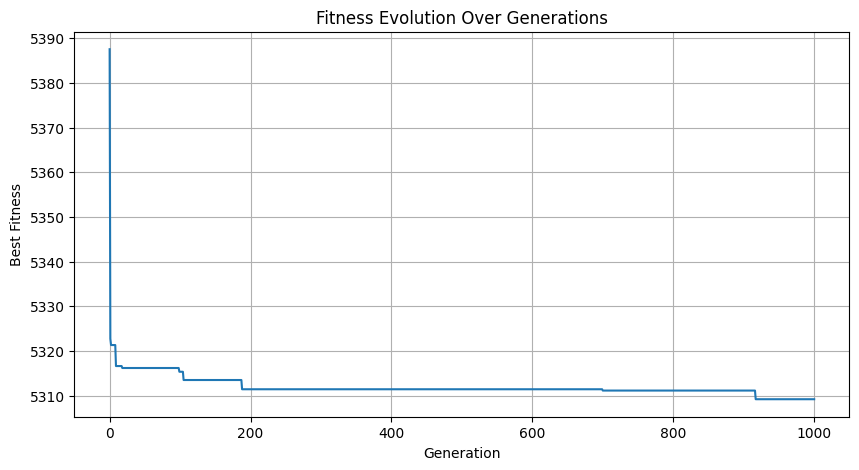

In [44]:
model.plot_fitness()

In [52]:
from ucimlrepo import fetch_ucirepo 

auto_mpg = fetch_ucirepo(id=9) 

X_mpg = auto_mpg.data.features 
y_mpg = auto_mpg.data.targets 
print(auto_mpg.variables) 
X_train_mpg = X_mpg.to_numpy()
y_train_mpg = y_mpg.to_numpy().reshape(-1, 1)

           name     role         type demographic description units  \
0  displacement  Feature   Continuous        None        None  None   
1           mpg   Target   Continuous        None        None  None   
2     cylinders  Feature      Integer        None        None  None   
3    horsepower  Feature   Continuous        None        None  None   
4        weight  Feature   Continuous        None        None  None   
5  acceleration  Feature   Continuous        None        None  None   
6    model_year  Feature      Integer        None        None  None   
7        origin  Feature      Integer        None        None  None   
8      car_name       ID  Categorical        None        None  None   

  missing_values  
0             no  
1             no  
2             no  
3            yes  
4             no  
5             no  
6             no  
7             no  
8             no  


Generation 0: Best fitness = nan
Generation 10: Best fitness = nan
Generation 20: Best fitness = nan
Generation 30: Best fitness = nan
Generation 40: Best fitness = nan
Generation 50: Best fitness = nan
Generation 60: Best fitness = nan
Generation 70: Best fitness = nan
Generation 80: Best fitness = nan
Generation 90: Best fitness = nan
Generation 100: Best fitness = nan
Generation 110: Best fitness = nan
Generation 120: Best fitness = nan
Generation 130: Best fitness = nan
Generation 140: Best fitness = nan
Generation 150: Best fitness = nan
Generation 160: Best fitness = nan
Generation 170: Best fitness = nan
Generation 180: Best fitness = nan
Generation 190: Best fitness = nan
Generation 200: Best fitness = nan
Generation 210: Best fitness = nan
Generation 220: Best fitness = nan
Generation 230: Best fitness = nan
Generation 240: Best fitness = nan
Generation 250: Best fitness = nan
Generation 260: Best fitness = nan
Generation 270: Best fitness = nan
Generation 280: Best fitness = 

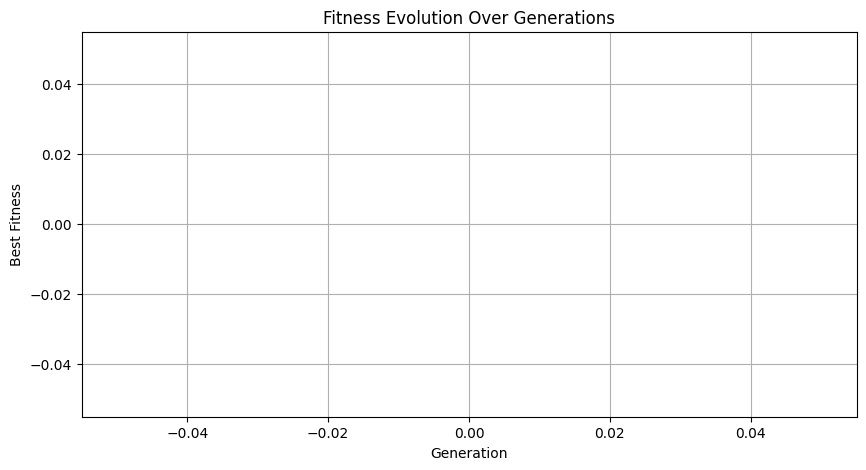

In [53]:
model2 = NeuralNetworkEvolution([X_train_mpg.shape[1], 10, 1], X_train_mpg, y_train_mpg,
                                 activation_fun="sigmoid", output_activation="linear", loss_fun="mse",
                                 population_size=50, random_draw=True)
model2.run(generations=int(1000), mutation_rate=0.2, k=5, verbose=True)
model2.plot_fitness()